In [1]:
import os, sys
_nb_cwd = os.getcwd()
if os.path.basename(_nb_cwd).lower() == 'novoboard':
    PROJECT_ROOT = os.path.dirname(_nb_cwd)
    NOVOBOARD_DIR = _nb_cwd
else:
    PROJECT_ROOT = _nb_cwd
    NOVOBOARD_DIR = next(
        (os.path.join(_nb_cwd, n) for n in ('novoboard', 'NovoBoard')
         if os.path.isdir(os.path.join(_nb_cwd, n))),
        os.path.join(_nb_cwd, 'novoboard'),
    )
sys.path.insert(0, NOVOBOARD_DIR)   # so `import config` finds the repo's config.py
os.chdir(PROJECT_ROOT)              # all paths below are relative to project root
print('Project root:', os.getcwd())

# import libraries
from __future__ import print_function


import os
import sys
import csv
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
import random
from multiprocessing import Pool
import time


import matplotlib
from matplotlib import pyplot
%matplotlib inline
from matplotlib_venn import venn3

from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord



Project root: /home/nagendra/ub/dl/De-Novo-Peptide-Sequencing


In [2]:
# Decoy FDR calculation

def read_denovo(denovo_csv, selected_features=None):
    denovo_psm = pd.read_csv(denovo_csv, keep_default_na=False)
    denovo_psm['feature_id'] = denovo_psm.apply(lambda row: row['Source File'].split('.mgf')[0] + '.mgf' + '||' + str(row['Scan']), axis=1)
    if selected_features:
        denovo_psm['selected_features'] = denovo_psm.apply(lambda row: row['feature_id'] in selected_features, axis=1)
        denovo_psm = denovo_psm[denovo_psm['selected_features']]
    return denovo_psm

def calculate_FDR(target_csv, decoy_csv, engine_score, fdr_list, selected_features=None):
    
    print("target_csv =", target_csv)
    print("decoy_csv =", decoy_csv)
    target_psm = read_denovo(target_csv, selected_features)
    decoy_psm = read_denovo(decoy_csv, selected_features)
    print("len(target_psm) =", len(target_psm)); print("len(decoy_psm) =", len(decoy_psm))
    dfs = pd.concat([target_psm, decoy_psm], keys=['target', 'decoy']).reset_index().rename(columns={'level_0': 'spectrum'})
    dfs['is_target'] = dfs.apply(lambda row: row['spectrum']=='target', axis=1)

    # target-decoy competition
    dfs.sort_values(by=[engine_score, 'is_target'], ascending=[False, False], inplace=True)
    # 1-1 competition on each scan id
#     dfs_fdr = dfs.drop_duplicates(subset=['feature_id'])
    # competition on whole dataset
    dfs_fdr = dfs
    dfs_fdr['feature_id'] = dfs_fdr.apply(lambda x: x['feature_id'] if x['is_target'] else x['feature_id']+'||decoy', axis=1)
    print("len(dfs) =", len(dfs))
    print("len(dfs_fdr) =", len(dfs_fdr))
    print("sum(dfs_fdr['is_target']) =", sum(dfs_fdr['is_target']))
    
    # fdr estimation
    cumsum = range(1, len(dfs_fdr) + 1)
    cumsum_target = np.cumsum(np.array(dfs_fdr['is_target'].astype(int)))
    cumsum_decoy = cumsum - cumsum_target
    estimated_fdr = cumsum_decoy / cumsum_target
    dfs_fdr['estimated_fdr'] = estimated_fdr

    score_list = []
    count_list = []
    for fdr in fdr_list:
        fdr_index = np.flatnonzero(estimated_fdr <= fdr)
        fdr_index = fdr_index[-1] if len(fdr_index) > 0 else 0
        score_list.append(dfs_fdr.iloc[fdr_index][engine_score])
        count_list.append(fdr_index + 1)

    return dfs, dfs_fdr, score_list, count_list



target_csv = novoboard_in_merged/casanovo/target/wastewater/wastewater_Sample2.csv
decoy_csv = novoboard_in_merged/casanovo/decoy/wastewater/wastewater_Sample2.csv
len(target_psm) = 26388
len(decoy_psm) = 26394
len(dfs) = 52782
len(dfs_fdr) = 52782
sum(dfs_fdr['is_target']) = 26388

=== casanovo ===
  FDR <= 1%: score cutoff = 0.8736, accepted = 2169
  FDR <= 5%: score cutoff = 0.5084, accepted = 6518
  FDR <= 10%: score cutoff = 0.2172, accepted = 8437
target_csv = novoboard_in_merged/instanovo/target/wastewater/wastewater_Sample2.csv
decoy_csv = novoboard_in_merged/instanovo/decoy/wastewater/wastewater_Sample2.csv
len(target_psm) = 26450
len(decoy_psm) = 26450
len(dfs) = 52900
len(dfs_fdr) = 52900
sum(dfs_fdr['is_target']) = 26450

=== instanovo ===
  FDR <= 1%: score cutoff = -0.0208, accepted = 2462
  FDR <= 5%: score cutoff = -0.7267, accepted = 8473
  FDR <= 10%: score cutoff = -1.7508, accepted = 11081
target_csv = novoboard_in_merged/instanovoplus/target/wastewater/wastewater_S

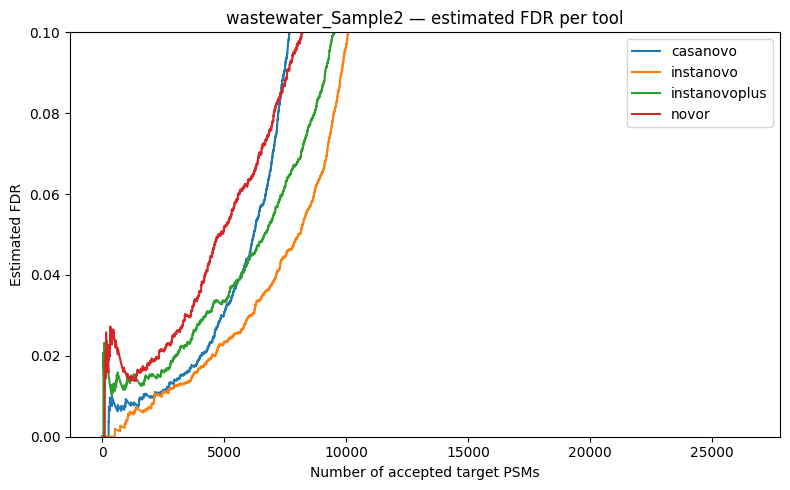

In [3]:
# Section 3 — estimated FDR per tool (wastewater_Sample2, no GT)
import os
os.makedirs('novoboard_out/wastewater_Sample2', exist_ok=True)

fdr_levels = [0.01, 0.05, 0.10]
engine_score = 'Score'
tools = ['casanovo', 'instanovo', 'instanovoplus', 'novor']

fdr_results = {}
for tool in tools:
    target_csv = f'novoboard_in_merged/{tool}/target/wastewater/wastewater_Sample2.csv'
    decoy_csv = f'novoboard_in_merged/{tool}/decoy/wastewater/wastewater_Sample2.csv'
    dfs, dfs_fdr, score_list, count_list = calculate_FDR(
        target_csv, decoy_csv, engine_score, fdr_levels)
    fdr_results[tool] = (dfs_fdr, score_list, count_list)
    print(f'\n=== {tool} ===')
    for fdr, sc, ct in zip(fdr_levels, score_list, count_list):
        print(f'  FDR <= {fdr*100:.0f}%: score cutoff = {sc:.4f}, accepted = {ct}')
    dfs_fdr.to_csv(f'novoboard_out/wastewater_Sample2/{tool}.fdr.csv', index=False)

fig, ax = pyplot.subplots(figsize=(8, 5))
for tool, (dfs_fdr, _, _) in fdr_results.items():
    target_estfdr = dfs_fdr.loc[dfs_fdr['is_target'], 'estimated_fdr'].values
    ax.plot(range(1, len(target_estfdr) + 1), target_estfdr, label=tool)
ax.set_xlabel('Number of accepted target PSMs')
ax.set_ylabel('Estimated FDR')
ax.set_ylim(0, 0.10)
ax.legend()
ax.set_title('wastewater_Sample2 — estimated FDR per tool')
pyplot.tight_layout()
pyplot.savefig('novoboard_out/wastewater_Sample2/estimated_fdr.png', dpi=150)
pyplot.show()
